In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from Emmanuel_scheme import Temp_prof,met_profiles,w_parcel
from GB84 import variables_2, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from kalman_filter_2 import kalman_filter as kf
from sklearn.metrics import mean_squared_error
from sympy import Symbol, Eq,exp, sqrt, lambdify,Piecewise,Pow,nan



c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


slice_str = "2024-07-05 19:59:00, 2024-07-07 19:59:00"
slice_tuple = tuple(slice_str.split(", "))

cabaw = xr.open_mfdataset(r'C:\Users\chari\Downloads\210618.HPC.NC')
cabaw_temp = xr.open_mfdataset(r'C:\Users\chari\Downloads\210618.TPB.NC')
#reference_date = np.datetime64("2024-07-01")

# Convert minutes into datetime
#datetime_values = reference_date + measurements.time.astype("timedelta64[m]")
#measurements['time'] = datetime_values

#july = cabaw.sel(time=slice(*slice_tuple))

In [2]:
cabaw_2 = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_multi_radiometer\*.nc')
cabaw_temp = cabaw_2.temperature

In [3]:
time_str = "2024-07-01 23:00:00"

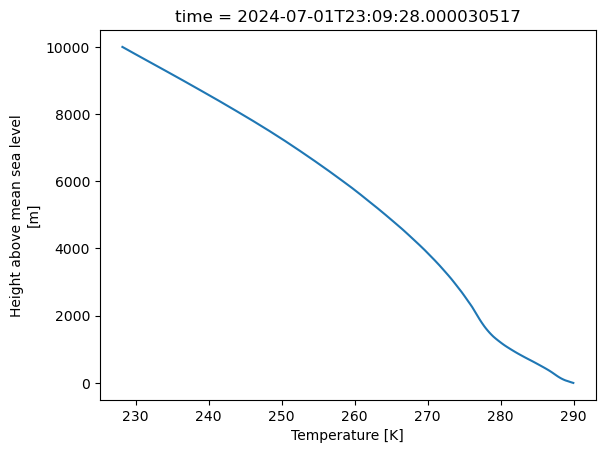

In [4]:
cabaw_2.temperature.sel(time=time_str,method='nearest').plot(y='height')

In [5]:
cabaw_2.relative_humidity.values

array([[0.7876756 , 0.7835641 , 0.77774584, ..., 0.28993693, 0.28140813,
        0.26810837],
       [0.84510535, 0.8343628 , 0.81964165, ..., 0.24761057, 0.24017079,
        0.22898217],
       [0.8323116 , 0.8231431 , 0.8105872 , ..., 0.29248285, 0.28369606,
        0.27039093],
       ...,
       [0.8211496 , 0.8025534 , 0.77737194, ..., 0.3162991 , 0.3049472 ,
        0.29071248],
       [0.7876192 , 0.77401847, 0.75531393, ..., 0.2878279 , 0.27845109,
        0.26667932],
       [0.83506495, 0.8177824 , 0.7945675 , ..., 0.33422166, 0.32543612,
        0.31309152]], dtype=float32)

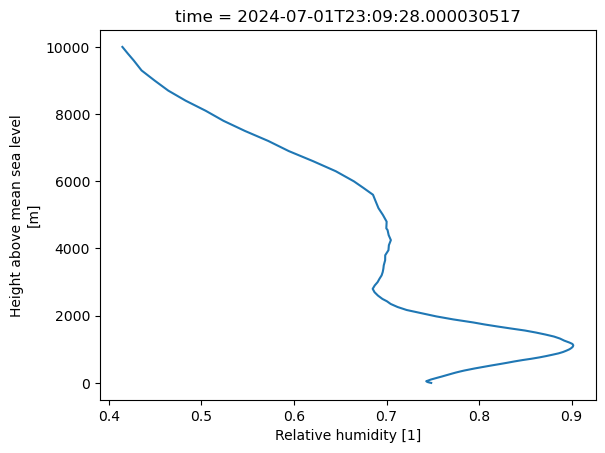

In [6]:
#plt.plot(cabaw_2.relative_humidity.sel(time=time_str,method='nearest'),cabaw_2.height)
cabaw_2.relative_humidity.sel(time=time_str,method='nearest').plot(y='height')

In [7]:
cabaw_2.relative_humidity

<xarray.DataArray 'relative_humidity' (time: 129, height: 93)> Size: 48kB
dask.array<concatenate, shape=(129, 93), dtype=float32, chunksize=(66, 93), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1kB 2024-07-01T00:09:26.999995708 ... 2024...
  * height   (height) float32 372B -1.0 9.0 24.0 ... 9.799e+03 9.999e+03
Attributes:
    units:                       1
    long_name:                   Relative humidity
    standard_name:               relative_humidity
    retrieval_type:              derived product
    retrieval_elevation_angles:  [ 4.2  4.8  5.4  6.6  8.4 11.4 14.4 19.2 30....
    retrieval_frequencies:       [22.24 23.04 23.84 25.44 26.24 27.84 31.4  5...

In [8]:
cabaw_2.relative_humidity.sel(time=time_str)

<xarray.DataArray 'relative_humidity' (time: 0, height: 93)> Size: 0B
dask.array<getitem, shape=(0, 93), dtype=float32, chunksize=(0, 93), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 0B 
  * height   (height) float32 372B -1.0 9.0 24.0 ... 9.799e+03 9.999e+03
Attributes:
    units:                       1
    long_name:                   Relative humidity
    standard_name:               relative_humidity
    retrieval_type:              derived product
    retrieval_elevation_angles:  [ 4.2  4.8  5.4  6.6  8.4 11.4 14.4 19.2 30....
    retrieval_frequencies:       [22.24 23.04 23.84 25.44 26.24 27.84 31.4  5...

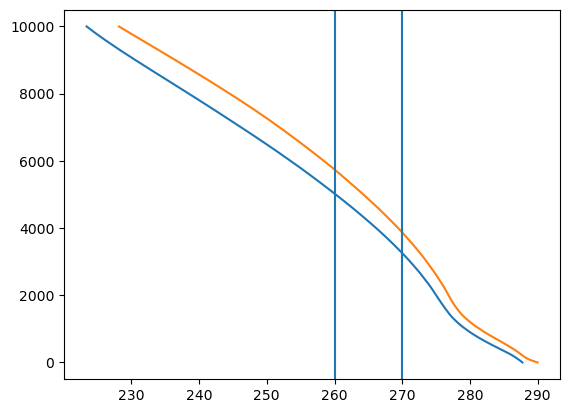

In [9]:
T_alt = np.zeros(len(cabaw_2.height))
#T_alt = np.zeros(len(cabaw.altitude))
T_alt[0] = 290
#for i in range(1,93):
    #T_alt[i] = T_alt[i-1] -6.5*(cabaw.altitude[i] - cabaw.altitude[i-1])/1000
#plt.plot(cabaw_temp.T_prof.sel(time='2021-06-18T15:01:52.000000000',method='nearest').values,cabaw.altitude)
plt.plot(cabaw_temp.sel(time='2021-06-18T15:01:52.000000000',method='nearest').values,cabaw_2.height)
#plt.plot(T_alt,cabaw.altitude)
#plt.plot(cabaw_temp.T_prof.sel(time='2025-03-03T04:00:09.000000000',method='nearest').values,cabaw.altitude)
plt.plot(cabaw_temp.sel(time=time_str,method='nearest').values,cabaw_2.height)
plt.axvline(260)
plt.axvline(270)
#plt.plot(cabaw.RH_prof.sel(time='2025-03-03T02:00:09.000000000',method='nearest').values,cabaw.altitude)
#plt.plot(cabaw.RH_prof.sel(time='2025-03-03T07:00:09.000000000',method='nearest').values,cabaw.altitude)

In [10]:
#my_temp = cabaw_temp.T_prof.sel(time='2021-06-18T15:01:52.000000000',method='nearest').values
#my_temp_2 = cabaw_temp.T_prof.sel(time='2025-03-03T12:00:09.000000000',method='nearest').values
my_temp = cabaw_temp.sel(time=time_str,method='nearest').values
#my_temp_2 = cabaw_temp.sel(time='2025-03-03T12:00:09.000000000',method='nearest').values
R=287
g = 9.81
#p = 100000/np.exp(g*cabaw.altitude/R/my_temp)
#p_2 = 100000/np.exp(g*cabaw.altitude/R/my_temp_2)
p = 100000/np.exp(g*cabaw_temp.height/R/my_temp)
Z = (p/100000)
#p_2 = 100000/np.exp(g*cabaw_temp.height/R/my_temp_2)
def specific_humidity_from_rh(T, RH, p):
    # T in Kelvin, RH in 0–1, p in Pa
    e_s = 6.112 * np.exp((17.67 * (T - 273.15)) / (T - 29.65)) * 100  # in Pa
    e = RH * e_s
    q = 0.622 * e / (p - 0.378 * e)
    return q



In [11]:
#q_v = specific_humidity_from_rh(my_temp, cabaw.RH_prof.sel(time='2021-06-18T15:01:52.000000000',method='nearest').values/100, p)
#q_v_2 = specific_humidity_from_rh(my_temp_2, cabaw.RH_prof.sel(time='2025-03-03T12:30:09.000000000',method='nearest').values/100, p_2)

q_v = specific_humidity_from_rh(my_temp, cabaw_2.relative_humidity.sel(time=time_str,method='nearest').values, p)
#q_v_2 = specific_humidity_from_rh(my_temp_2, cabaw_2.relative_humidity.sel(time='2025-03-03T12:30:09.000000000',method='nearest').values, p_2)

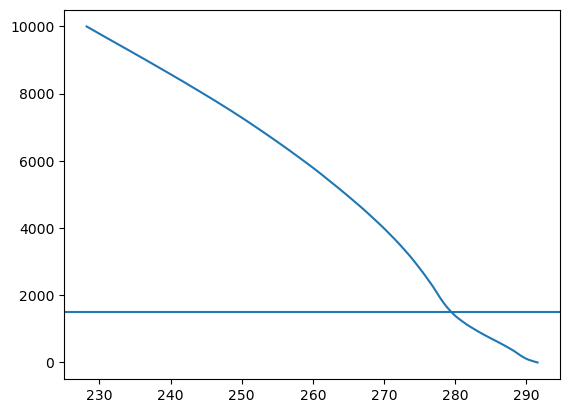

In [13]:
T_v_env = my_temp*(1+0.61*q_v)
#T_v_env_2 = my_temp_2*(1+0.61*q_v_2)
#plt.plot(T_v_env,cabaw.altitude)
#plt.plot(T_v_env_2,cabaw.altitude)
plt.plot(T_v_env,cabaw_2.height)
#plt.plot(T_v_env_2,cabaw_2.height)
#plt.xlim(270,280)
plt.axhline(1500)


In [14]:
import numpy as np
from scipy.optimize import fsolve
from sympy import Symbol, Eq,exp, sqrt, lambdify

R_d = 287.05
epsilon = 0.622 
A_1 = 8e-4  # (kg/(m·s²·K^3.5))
A = 2.5e6  # (J/kg)
B = 2.38e3  # (J/(kg K))
cp = 1001
p_n = p[0].values  # (kg/(m·s²))
def w(T,P):
    #mixing ratio
    return epsilon*A_1*(T - 223.15)**3.5/P

def L(T):
    #latent heat of condensation
    return A - B*(T - 273.15)

def met_profiles(T_surf,p_surf,p_t):
    p_air = np.linspace(p_surf, p_t, 1000)
    T_air = T_surf*(p_air/p_surf)**0.286
    return p_air, T_air

def e_s(T):
    T_C = T - 273.15  # convert to Celsius

    return np.where(
            T >= 273.15,
            np.exp(34.494 - 4924.99 / (T_C + 237.1)) / (T_C + 105) ** 1.57,
            np.exp(43.494 - 6545.8 / (T_C + 278)) / (T_C + 868) ** 2
        )

def w_sat(T,P):
    e_sat = e_s(T)
    return 0.622*e_s(T)/(P- e_sat)

def e_s_symbolic(T):
    T_C = T - 273.15
    return Piecewise(
        (exp(34.494 - 4924.99 / (T_C + 237.1)) / Pow(T_C + 105, 1.57), T >= 273.15),
        (exp(43.494 - 6545.8 / (T_C + 278)) / Pow(T_C + 868, 2), True)
    )

def w_sat_symbolic(T, P):
    e_sat = e_s_symbolic(T)
    return 0.622 * e_sat / (P - e_sat)

def Temp_prof(T_surf,p_surf,T_d,p_air,T_air):

    p_s = (1/((T_surf - T_d)/223.15 + 1))**3.5 * p_surf
    print(p_s)
    T_s = (1/((T_surf - T_d)/223.15 + 1))* T_surf
    print(T_s)
    theta_moist_parcel = T_s*(p_n/p_s)**0.286*np.exp(L(T_s)*w_sat(T_s,p_s)/(cp*T_s))
    theta_dry = T_surf*(p_n/p_surf)**0.286
    #theta_moist_parcel = T_surf*(1e5/p_surf)**(0.2854*(1-0.28*1e-3*w(T_d,p_surf)))*np.exp((3.376/T_s - 0.00254)*w(T_d,p_surf)*(1+0.81*1e-3*w(T_d,p_surf)))
    print(theta_moist_parcel)
    lcl_index = (np.abs(p_air - p_s)).argmin()
    #print(np.abs(p_air - p_s))
    T_arr = theta_dry*(p_air/p_n)**0.286*np.ones(len(T_air))
    #T_arr[lcl_index] = T_s

    for i in range(lcl_index,len(p_air)):
        #print(i)
        T_parcel = Symbol('T_parcel')
        T_func = Eq(theta_moist_parcel,T_parcel * (p_n / p_air[i])**0.286 * exp((A - B * (T_parcel - 273.15)) * w_sat_symbolic(T_parcel,p_air[i]) / (cp * T_parcel)))
        T_solve = lambdify(T_parcel, T_func.lhs - T_func.rhs, 'numpy')
        T_parcel = fsolve(T_solve, T_arr[i-1])
        T_arr[i] = T_parcel
        print(T_parcel)

    return T_arr,lcl_index

In [15]:
#RH = cabaw.RH_prof.sel(time='2021-06-18T15:01:52.000000000',method='nearest').values[0]
RH = cabaw_2.relative_humidity.sel(time=time_str,method='nearest').values[0]
T_surf_C = my_temp[0] - 273.15
if RH<1:
    alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH) #from http://dx.doi.org/10.31648/ts.5425
else:

    alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
    
T_d= 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

In [16]:
temp_parcel,lcl_index = Temp_prof(my_temp[0],p[0].values,T_d,p.values,my_temp)

93268.20723104774
284.2451188563581
313.4084998491077
[284.14911105]
[283.93630396]
[283.72249625]
[283.50771933]
[283.29212319]
[283.07570411]
[282.85843003]
[282.64034939]
[282.42154295]
[282.20204825]
[281.98172946]
[281.76062476]
[281.53870677]
[281.31617999]
[281.09319097]
[280.86966821]
[280.53298774]
[280.19479314]
[279.85536538]
[279.51529687]
[279.17407114]
[278.83172744]
[278.48816144]
[278.1433816]
[277.79760855]
[277.45032334]
[276.92704789]
[276.40095611]
[275.27827389]
[274.74059048]
[274.19747251]
[273.71079278]
[273.28254366]
[272.69593138]
[272.11138968]
[271.51886956]
[270.91960762]
[270.31311293]
[269.69904668]
[269.0761618]
[268.44469528]
[267.80532426]
[267.15779195]
[266.16885701]
[265.15835434]
[264.12848898]
[263.07471221]
[261.99776373]
[260.89910715]
[259.77747419]
[259.39777127]
[257.85018263]
[256.26056991]
[254.62694121]
[252.945973]
[251.22595115]
[249.45940042]
[247.64208564]
[244.83862805]
[241.9400808]
[238.95238265]
[235.88288856]
[232.7279079]
[229.49

(0.0, 6000.0)

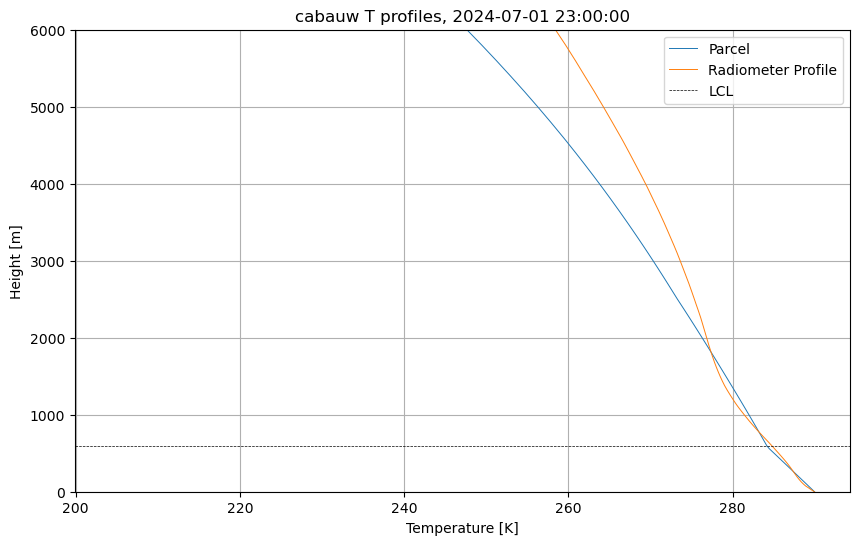

In [17]:
T_dry = my_temp[0]*(p/p[0])**0.286
plt.figure(figsize=(10,6))

#plt.plot(T_dry,cabaw_2.height,label = 'dry adiabat',linewidth=0.7)
plt.plot(temp_parcel,cabaw_2.height,label='Parcel',linewidth=0.7)
plt.plot(my_temp,cabaw_2.height,label = 'Radiometer Profile',linewidth=0.7)
plt.grid()
plt.axhline(cabaw_2.height[lcl_index],color='black',linewidth=0.5,linestyle='--',label='LCL')
plt.ylabel('Height [m]')
plt.xlabel('Temperature [K]')
plt.title(f'cabauw T profiles, {time_str}')
plt.legend()
plt.ylim(0,6000)

In [18]:
lcl_index

21

In [19]:
def e_s(T):
    T_C = T - 273.15  # convert to Celsius
    return np.where(
        T >= 273.15,
        np.exp(34.494 - 4924.99 / (T_C + 237.1)) / (T_C + 105) ** 1.57,
        np.exp(43.494 - 6545.8 / (T_C + 278)) / (T_C + 868) ** 2
    )
def w_sat(T,P):
    e_sat = e_s(T)
    return 0.622*e_s(T)/(P- e_sat)

def T_v(T_d,p_surf,p_air,T_arr,lcl_index):

    q_t = w_sat(T_d,p_surf)
    q_v = np.zeros(len(T_arr))
    q_l = np.zeros(len(T_arr))
    q_v[0:lcl_index] = q_t*np.ones(lcl_index)
    q_v[lcl_index:] = w_sat(T_arr[lcl_index:],p_air[lcl_index:])
    q_l[0:lcl_index] = 0
    q_l[lcl_index:] = q_t - q_v[lcl_index:]

    T_v_moist = T_arr*(1 +0.61*q_v)# - q_l)
    print(q_t)
    return T_v_moist,q_v

In [20]:
T_v_parcel,q_v_parcel = T_v(T_d,p[0].values,p.values,temp_parcel,lcl_index)

0.009043527388342784


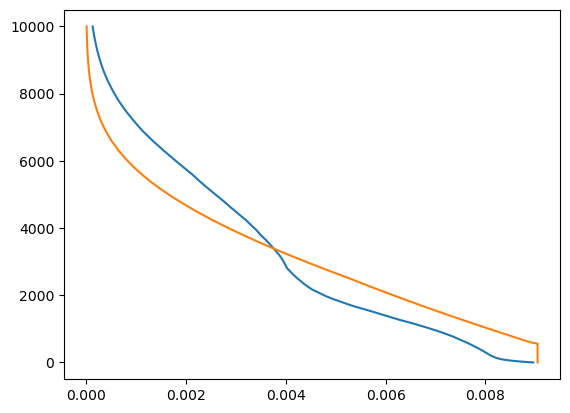

In [21]:
plt.plot(q_v,cabaw_2.height)
plt.plot(q_v_parcel,cabaw_2.height)

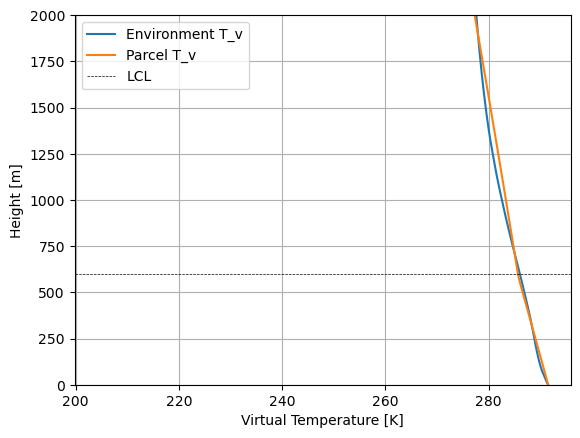

In [22]:

#print(q_v.values)
plt.plot(T_v_env,cabaw_2.height,label='Environment T_v')
plt.plot(T_v_parcel,cabaw_2.height,label='Parcel T_v') 

plt.axhline(cabaw_2.height[lcl_index],color='black',linewidth=0.5,linestyle='--',label = 'LCL')
#plt.axhline(cabaw.altitude[index+1])
#plt.ylim(1000,1400)
plt.xlabel('Virtual Temperature [K]')
plt.ylabel('Height [m]')
plt.grid()
plt.ylim(0,2000)
plt.legend()

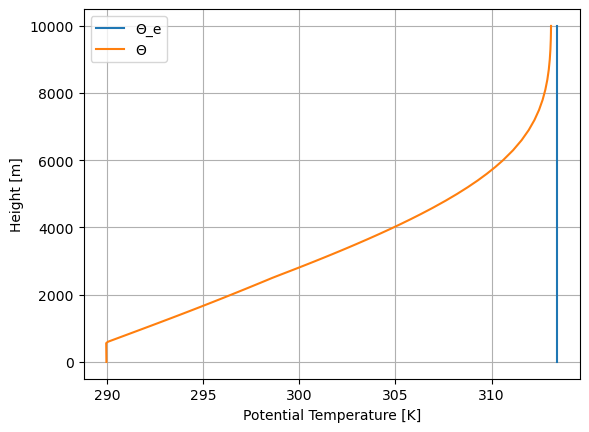

In [23]:
theta = temp_parcel*(p_n/p)**(0.2854)
theta_e = temp_parcel * (p_n / p.values)**0.286 * np.exp((A - B * (temp_parcel- 273.15)) * w_sat(temp_parcel, p.values) / (cp * temp_parcel))
theta_under_lcl = theta_e[lcl_index]
theta_e[0:lcl_index] = theta_under_lcl*np.ones(lcl_index)
plt.plot(theta_e,cabaw_2.height,label='Θ_e')
plt.plot(theta,cabaw_2.height,label='Θ')
plt.xlabel('Potential Temperature [K]')
plt.ylabel('Height [m]')
plt.legend()
#plt.ylim(2000)
plt.grid()

In [24]:
grav   = 9.81
cp     = 1005.
rd     = 287.05
rlv    = 2.5e6
es0    = 611
beta   = 0.067
tmelt = 273.16
es0    = 611
beta   = 0.067
eps0   = 0.622



In [25]:

ql_p = np.zeros(len(cabaw_2.height))

theta_p = my_temp[0]
Tl_p = theta_p - g*cabaw_2.height/cp
ql_p[lcl_index:] = (q_v[0].values - w_sat(Tl_p[lcl_index:],p[lcl_index:]))/(1 + rlv*beta/cp*w_sat(Tl_p[lcl_index:],p[lcl_index:]))
Tp =  Tl_p + rlv/cp*ql_p
Tv_p = Tp*(1 + 0.608*(q_v[0].values*np.ones(len(ql_p)) - ql_p) - ql_p)

In [26]:
w_sat(Tl_p[lcl_index:],p[lcl_index:])

<xarray.DataArray 'height' (height: 72)> Size: 576B
array([8.88565886e-03, 8.69748589e-03, 8.51278915e-03, 8.33146362e-03,
       8.15347501e-03, 7.97874633e-03, 7.80724931e-03, 7.63890078e-03,
       7.47364441e-03, 7.31145202e-03, 7.15227668e-03, 6.99605441e-03,
       6.84277435e-03, 6.69231324e-03, 6.54465535e-03, 6.39974859e-03,
       6.18751043e-03, 5.98125469e-03, 5.78083162e-03, 5.58601447e-03,
       5.39675459e-03, 5.21289974e-03, 5.03437134e-03, 4.86101714e-03,
       4.68601593e-03, 4.49697780e-03, 4.22607130e-03, 3.96969189e-03,
       3.47337498e-03, 3.25816536e-03, 3.05500069e-03, 2.88399226e-03,
       2.74138585e-03, 2.54857189e-03, 2.36795886e-03, 2.19890637e-03,
       2.04070586e-03, 1.89274519e-03, 1.75445818e-03, 1.62531472e-03,
       1.50476927e-03, 1.39228136e-03, 1.28738795e-03, 1.14333650e-03,
       1.01395124e-03, 8.97846749e-04, 7.93872678e-04, 7.00879460e-04,
       6.17800306e-04, 5.43702767e-04, 5.20853173e-04, 4.37881446e-04,
       3.67031307e-04, 3.06714965e-04, 2.55531160e-04, 2.12195109e-04,
       1.75644159e-04, 1.44923760e-04, 1.07918534e-04, 7.97304843e-05,
       5.84240681e-05, 4.24479464e-05, 3.05737780e-05, 2.18229775e-05,
       1.54311794e-05, 1.08033504e-05, 7.48652421e-06, 5.13194762e-06,
       3.47863857e-06, 2.33026728e-06, 1.77168753e-06, 1.33920879e-06])
Coordinates:
  * height   (height) float32 288B 599.0 639.0 679.0 ... 9.799e+03 9.999e+03

In [27]:
q_v_parcel

array([9.04352739e-03, 9.04352739e-03, 9.04352739e-03, 9.04352739e-03,
       9.04352739e-03, 9.04352739e-03, 9.04352739e-03, 9.04352739e-03,
       9.04352739e-03, 9.04352739e-03, 9.04352739e-03, 9.04352739e-03,
       9.04352739e-03, 9.04352739e-03, 9.04352739e-03, 9.04352739e-03,
       9.04352739e-03, 9.04352739e-03, 9.04352739e-03, 9.04352739e-03,
       9.04352739e-03, 8.90045829e-03, 8.81722269e-03, 8.73409818e-03,
       8.65110380e-03, 8.56830371e-03, 8.48570214e-03, 8.40329263e-03,
       8.32109930e-03, 8.23915782e-03, 8.15748707e-03, 8.07604165e-03,
       7.99484116e-03, 7.91388100e-03, 7.83324053e-03, 7.75297635e-03,
       7.67306588e-03, 7.55373136e-03, 7.43510536e-03, 7.31729960e-03,
       7.20052785e-03, 7.08462038e-03, 6.96960057e-03, 6.85544364e-03,
       6.74216302e-03, 6.62984037e-03, 6.51831775e-03, 6.35271597e-03,
       6.18916356e-03, 5.84993671e-03, 5.69216144e-03, 5.53585083e-03,
       5.39837960e-03, 5.27943092e-03, 5.10031611e-03, 4.92056159e-03,
      

In [28]:
lcl_index

21

In [29]:
theta = my_temp[0]
T_v_dry = theta*(p/p[0])**(0.2854)*(1+0.61*q_v[0].values)

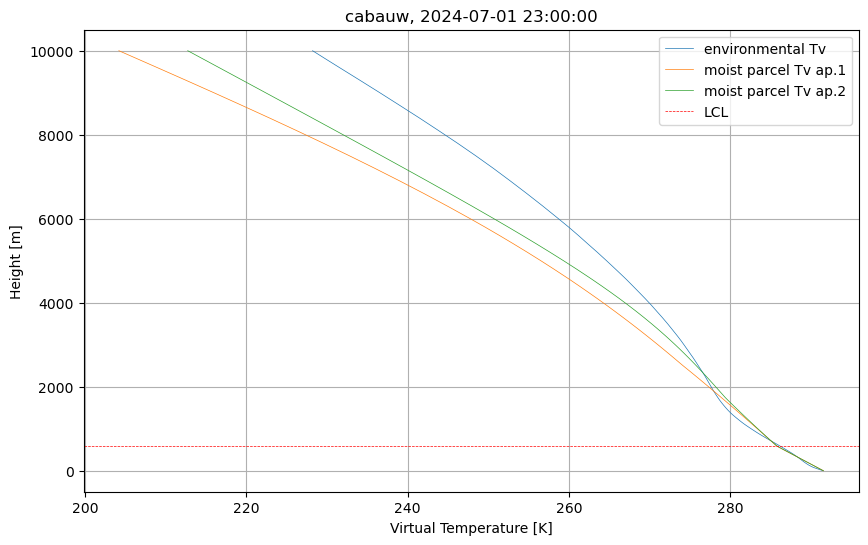

In [30]:
#plt.plot(Tv_p,cabaw.altitude)
#plt.plot(T_v_env,cabaw.altitude)
plt.figure(figsize=(10,6))
plt.plot(T_v_env,cabaw_2.height,label='environmental Tv',linewidth=0.5)   
plt.plot(T_v_parcel,cabaw_2.height,label='moist parcel Tv ap.1',linewidth=0.5)

plt.plot(Tv_p,cabaw_2.height,label='moist parcel Tv ap.2',linewidth=0.5)

#plt.plot(T_v_dry,cabaw_2.height,label='dry air T_v')

plt.axhline(cabaw_2.height[lcl_index],color='red',linewidth=0.5,linestyle='--',label='LCL')
plt.xlabel('Virtual Temperature [K]')
plt.ylabel('Height [m]')
plt.title(f'cabauw, {time_str}')
#plt.ylim(0,2000)
plt.grid()
plt.legend()

In [31]:
print(np.mean(Tv_p[lcl_index:] - T_v_env[lcl_index:]))

print(np.mean(Tv_p[lcl_index:] - my_temp[lcl_index:]))



<xarray.DataArray 'height' ()> Size: 8B
array(-3.33845094)
<xarray.DataArray 'height' ()> Size: 8B
array(-2.65569534)


In [32]:
ds = xr.open_dataset('specific_humidity_profiles_more.nc')

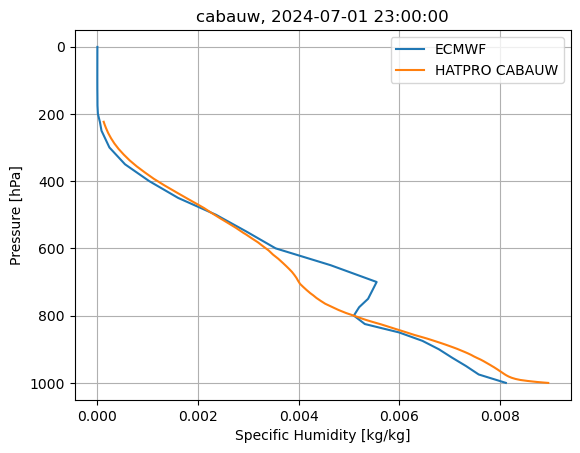

In [33]:
q_era = ds.q.sel(valid_time=time_str,latitude=51.96,longitude=4.9,method='nearest')
plt.plot(q_era.values,ds.q.pressure_level,label='ECMWF')
plt.plot(q_v,p.values/100,label='HATPRO CABAUW')
plt.gca().invert_yaxis()
plt.title(f'cabauw, {time_str}')
plt.xlabel('Specific Humidity [kg/kg]')
plt.ylabel('Pressure [hPa]')
plt.grid()
plt.legend()

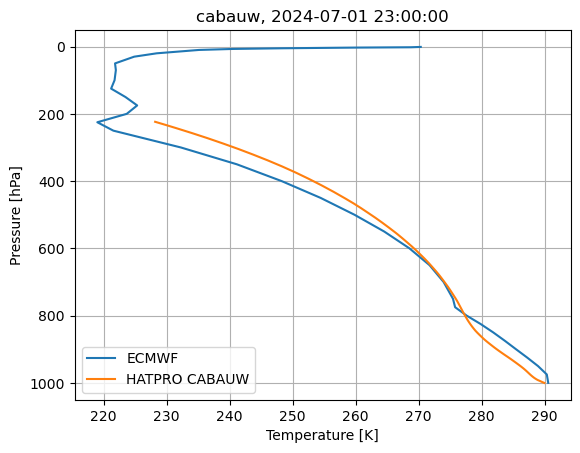

In [34]:
ds_temp = xr.open_dataset('temperature_profiles_more.nc')
#ds = xr.open_dataset('specific_humidity_profiles_all.nc')
#print(ds)

T_era = ds_temp.t.sel(valid_time=time_str,latitude=51.96,longitude=4.9,method='nearest')

plt.plot(T_era.values,ds_temp.t.pressure_level,label='ECMWF')
plt.plot(my_temp,p.values/100,label='HATPRO CABAUW')
plt.gca().invert_yaxis()
plt.title(f'cabauw, {time_str}')
plt.xlabel('Temperature [K]')
plt.ylabel('Pressure [hPa]')
plt.grid()
plt.legend()

In [35]:
q_era

<xarray.DataArray 'q' (pressure_level: 37)> Size: 148B
array([8.116592e-03, 7.577289e-03, 7.325996e-03, 7.048000e-03, 6.785262e-03,
       6.459188e-03, 5.995866e-03, 5.315848e-03, 5.097304e-03, 5.202394e-03,
       5.380177e-03, 5.550394e-03, 4.634732e-03, 3.544103e-03, 2.963564e-03,
       2.357646e-03, 1.608053e-03, 1.033090e-03, 5.524209e-04, 2.426632e-04,
       8.521142e-05, 5.508539e-05, 1.380890e-05, 5.475458e-06, 4.617496e-06,
       2.910861e-06, 2.642971e-06, 2.765210e-06, 3.029251e-06, 3.195733e-06,
       3.286329e-06, 3.519423e-06, 3.596486e-06, 3.680455e-06, 3.806530e-06,
       3.911919e-06, 4.047015e-06], dtype=float32)
Coordinates:
    number          int64 8B ...
    valid_time      datetime64[ns] 8B 2024-07-09
  * pressure_level  (pressure_level) float64 296B 1e+03 975.0 950.0 ... 2.0 1.0
    latitude        float64 8B 52.0
    longitude       float64 8B 5.0
    expver          <U4 16B ...
Attributes: (12/31)
    GRIB_paramId:                             133
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      357
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           q
    GRIB_totalNumber:                         0
    GRIB_units:                               kg kg**-1
    long_name:                                Specific humidity
    units:                                    kg kg**-1
    standard_name:                            specific_humidity

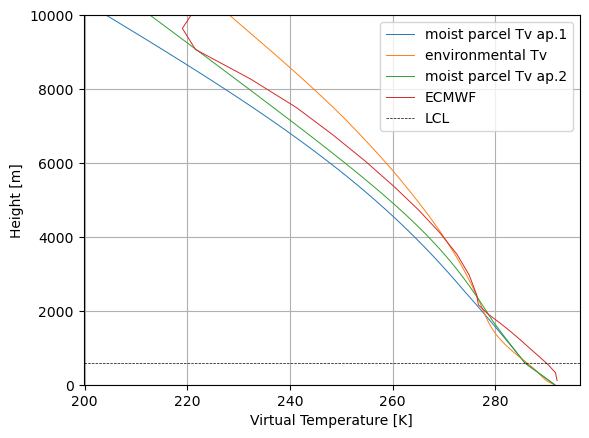

In [36]:
T_v_era_1 = T_era*(1+0.61*q_era)
Z_era = R*T_era/(g)*np.log(1013.25/T_era.pressure_level)

plt.plot(T_v_parcel,cabaw_2.height,label='moist parcel Tv ap.1',linewidth=0.7)
plt.plot(T_v_env,cabaw_2.height,label='environmental Tv',linewidth=0.7)
plt.plot(Tv_p,cabaw_2.height,label='moist parcel Tv ap.2',linewidth=0.7)
plt.plot(T_v_era_1,Z_era,label='ECMWF',linewidth=0.7)
plt.axhline(cabaw_2.height[lcl_index],color='black',linewidth=0.5,linestyle='--',label='LCL')
plt.ylim(0,10000)
plt.xlabel('Virtual Temperature [K]')    
plt.ylabel('Height [m]')
plt.legend()
plt.grid()

In [37]:
T_era.pressure_level

<xarray.DataArray 'pressure_level' (pressure_level: 37)> Size: 296B
array([1000.,  975.,  950.,  925.,  900.,  875.,  850.,  825.,  800.,  775.,
        750.,  700.,  650.,  600.,  550.,  500.,  450.,  400.,  350.,  300.,
        250.,  225.,  200.,  175.,  150.,  125.,  100.,   70.,   50.,   30.,
         20.,   10.,    7.,    5.,    3.,    2.,    1.])
Coordinates:
    number          int64 8B ...
    valid_time      datetime64[ns] 8B 2024-07-09
  * pressure_level  (pressure_level) float64 296B 1e+03 975.0 950.0 ... 2.0 1.0
    latitude        float64 8B 52.0
    longitude       float64 8B 5.0
    expver          <U4 16B ...
Attributes:
    long_name:         pressure
    units:             hPa
    positive:          down
    stored_direction:  decreasing
    standard_name:     air_pressure

### Running the Model with ERA5 data


In [38]:
data_era = xr.open_dataset('profiles_era.nc')

#temp = xr.open_dataset('temperature_profiles_more.nc')
Temp_era = data_era.t.sel(latitude=51.96,longitude=4.9,method='nearest')



press = Temp_era.pressure_level*100

#humid_era = xr.open_dataset('specific_humidity_profiles_more.nc')
q_era = data_era.q.sel(latitude=51.96,longitude=4.9,method='nearest')

T_v_era = Temp_era*(1+0.61*q_era)

Z_era = data_era.z.sel(latitude=51.96,longitude=4.9,method='nearest')/g

data_surf_era = xr.open_dataset('surface_era.nc')

press_surface = data_surf_era.sp.sel(latitude=51.96,longitude=4.9,method='nearest')
T_surface = data_surf_era.t2m.sel(latitude=51.96,longitude=4.9,method='nearest')
#dew_temp = xr.open_dataset('surface_dew_point_temperature.nc')
T_d_era = data_surf_era.d2m.sel(latitude=51.96,longitude=4.9,method='nearest')
Z_surf = 2*np.ones(len(press_surface))

In [39]:
press

<xarray.DataArray 'pressure_level' (pressure_level: 37)> Size: 296B
array([100000.,  97500.,  95000.,  92500.,  90000.,  87500.,  85000.,
        82500.,  80000.,  77500.,  75000.,  70000.,  65000.,  60000.,
        55000.,  50000.,  45000.,  40000.,  35000.,  30000.,  25000.,
        22500.,  20000.,  17500.,  15000.,  12500.,  10000.,   7000.,
         5000.,   3000.,   2000.,   1000.,    700.,    500.,    300.,
          200.,    100.])
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 296B 1e+03 975.0 950.0 ... 2.0 1.0
    latitude        float64 8B 52.0
    longitude       float64 8B 5.0

#### Runs

In [40]:
#inputs

#temperature on the ground
T_surf = T_surface.values #[K]
T_prof = Temp_era.values
#T_air = T_prof.copy()
#np.concatenate([a.reshape(24, 1), b], axis=1)
T_air = np.concatenate([T_surf.reshape(len(T_surf), 1), T_prof], 1)

#pressure
p_surf = press_surface.values #[Pa]
p_air = np.tile(press.values,(len(p_surf),1))
p_air = np.concatenate([p_surf.reshape(len(p_surf), 1), p_air], 1) #[Pa]
#dew point temperature
T_d_arr = T_d_era.values     #[K]

Z_prof = Z_era.values
Z_height = np.concatenate([Z_surf.reshape(len(Z_surf), 1), Z_prof], 1) #[m]
#state
X = np.zeros(len(T_surf))
X[0] = 0   #initial state in kg/m2
#X = july.lwp.sel(time=measurements_used.time,method='nearest').values
#Sigma = np.zeros(len(T_surf))
#Sigma[0] = 1 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s
modis_press = 487.17*100 #Pa

In [41]:
p_air

array([[1.01707938e+05, 1.00000000e+05, 9.75000000e+04, 9.50000000e+04,
        9.25000000e+04, 9.00000000e+04, 8.75000000e+04, 8.50000000e+04,
        8.25000000e+04, 8.00000000e+04, 7.75000000e+04, 7.50000000e+04,
        7.00000000e+04, 6.50000000e+04, 6.00000000e+04, 5.50000000e+04,
        5.00000000e+04, 4.50000000e+04, 4.00000000e+04, 3.50000000e+04,
        3.00000000e+04, 2.50000000e+04, 2.25000000e+04, 2.00000000e+04,
        1.75000000e+04, 1.50000000e+04, 1.25000000e+04, 1.00000000e+04,
        7.00000000e+03, 5.00000000e+03, 3.00000000e+03, 2.00000000e+03,
        1.00000000e+03, 7.00000000e+02, 5.00000000e+02, 3.00000000e+02,
        2.00000000e+02, 1.00000000e+02],
       [1.01690312e+05, 1.00000000e+05, 9.75000000e+04, 9.50000000e+04,
        9.25000000e+04, 9.00000000e+04, 8.75000000e+04, 8.50000000e+04,
        8.25000000e+04, 8.00000000e+04, 7.75000000e+04, 7.50000000e+04,
        7.00000000e+04, 6.50000000e+04, 6.00000000e+04, 5.50000000e+04,
        5.00000000e+04,

In [42]:

def relative_humidity(t_air, t_dew):
    """
    t_air and t_dew in Celsius
    Returns RH in %
    """
    rh = 100 * (np.exp((17.67 * t_dew) / (t_dew + 243.5)) / 
                np.exp((17.67 * t_air) / (t_air + 243.5)))
    return rh

RH_surf = relative_humidity(T_surf, T_d_era.values)

q_v_surf = specific_humidity_from_rh(T_surf,RH_surf/100, p_surf)
q_v_air = np.concatenate([q_v_surf.reshape(len(q_v_surf), 1), q_era.values], 1) #[m]

In [43]:
q_v_air

array([[1.09908646e-02, 8.11659172e-03, 7.57728890e-03, 7.32599571e-03,
        7.04799965e-03, 6.78526238e-03, 6.45918772e-03, 5.99586591e-03,
        5.31584769e-03, 5.09730354e-03, 5.20239398e-03, 5.38017694e-03,
        5.55039430e-03, 4.63473238e-03, 3.54410335e-03, 2.96356413e-03,
        2.35764636e-03, 1.60805276e-03, 1.03308959e-03, 5.52420912e-04,
        2.42663184e-04, 8.52114172e-05, 5.50853874e-05, 1.38089044e-05,
        5.47545824e-06, 4.61749551e-06, 2.91086053e-06, 2.64297068e-06,
        2.76520950e-06, 3.02925127e-06, 3.19573337e-06, 3.28632905e-06,
        3.51942344e-06, 3.59648584e-06, 3.68045494e-06, 3.80653000e-06,
        3.91191861e-06, 4.04701495e-06],
       [1.08973915e-02, 8.05342197e-03, 7.56084919e-03, 7.32815266e-03,
        7.07542896e-03, 6.83462620e-03, 6.53379038e-03, 6.17419183e-03,
        5.66536188e-03, 5.39422035e-03, 5.57739753e-03, 5.88879175e-03,
        5.57596795e-03, 4.42888541e-03, 3.23512359e-03, 2.64459639e-03,
        2.23045028e-03,

In [44]:

index_p  = np.argmin(np.abs(p_air - 20000))
T_arr = np.zeros((len(T_air),index_p))
lcl_index_arr = np.zeros(len(T_surf))
T_v_save_env = np.zeros((len(T_air),index_p))
T_v_save_parcel = np.zeros((len(T_air),index_p))
for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s = variables_2.calculate_cloud_base(T_0, T_d, p_0)

    
    #implementing the emmanuel scheme
    p_air_prof = p_air[i,:index_p]
    T_air_prof = T_air[i,:index_p]
    T_arr[i,:],lcl_index_arr[i] = Temp_prof(T_0,p_0,T_d,p_air_prof,T_air_prof)
    T_v_parcel = T_v(T_d,p_0,p_air_prof,T_arr[i,:],int(lcl_index_arr[i]))[0]
    T_v_env = T_air_prof*(1+0.61*q_v_air[i,:index_p])
    T_v_save_env[i] = T_v_env
    T_v_save_parcel[i] = T_v_parcel 

96677.74119164857
285.4849589411892
312.4785786663572
[285.84977153]
[284.72740338]
[283.5641175]
[282.35681984]
[281.10207797]
[279.79607548]
[278.43455964]
[277.01278185]
[275.52542982]
[273.96655131]
[270.75424159]
[267.18974275]
[263.12687367]
[258.4516488]
[253.03180329]
[246.72755425]
[239.40879898]
[230.96378824]
[221.27435434]
[210.14514768]
[203.93132418]
0.009450901361497491
96586.05645905009
285.29997992605195
312.09611631360167
[285.70671585]
[284.5815994]
[283.4153955]
[282.20499607]
[280.9469536]
[279.63743549]
[278.27217187]
[276.84639619]
[275.35477779]
[273.79134616]
[270.57850455]
[267.00005106]
[262.92143341]
[258.2291092]
[252.79200124]
[246.47247347]
[239.14317434]
[230.69453406]
[221.00882158]
[209.88951364]
[203.68246694]
0.009344265322734068
96077.90658405879
285.12695813995856
312.24234580790124
[284.63744399]
[283.47235846]
[282.26314779]
[281.00637021]
[279.69819931]
[278.33437178]
[276.91012789]
[275.42014399]
[273.8584565]
[270.64583839]
[267.07272881]
[263

In [45]:
np.shape(q_v_air[i,:index_p])

(23,)

In [46]:
Temp_era.valid_time[0].values

numpy.datetime64('2024-07-09T00:00:00.000000000')

Text(0.5, 1.0, '2024-07-09T16:00:00.000000000')

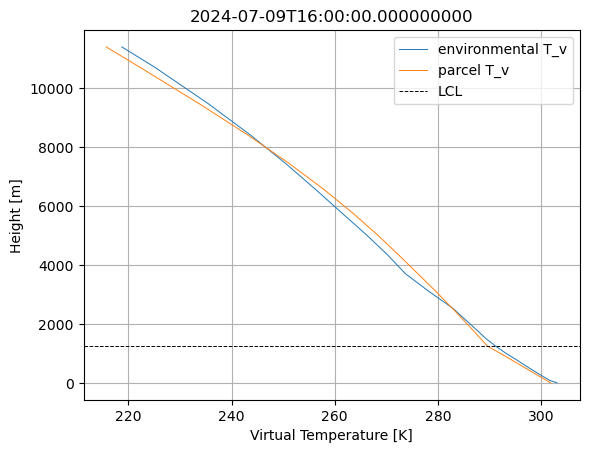

In [47]:
hour_index = 16
plt.plot(T_v_save_env[hour_index],Z_height[hour_index,:index_p],linewidth=0.7,label='environmental T_v')
plt.plot(T_v_save_parcel[hour_index],Z_height[hour_index,:index_p],linewidth=0.7,label='parcel T_v')
plt.axhline(y=Z_height[hour_index,int(lcl_index_arr[hour_index])],linestyle='--',color='black',linewidth=0.7,label='LCL')
#plt.ylim(0,2000)
plt.grid()
plt.xlabel('Virtual Temperature [K]')
plt.ylabel('Height [m]')
plt.legend()
plt.title(f'{Temp_era.valid_time[hour_index].values}')

In [48]:
int(lcl_index_arr[15])
#lcl_index_arr

6

In [49]:
Z_height

array([[2.00000000e+00, 1.44052887e+02, 3.60501831e+02, 5.81724609e+02,
        8.07543701e+02, 1.03807092e+03, 1.27361780e+03, 1.51439209e+03,
        1.76060132e+03, 2.01234460e+03, 2.27014551e+03, 2.53537988e+03,
        3.09281689e+03, 3.68681226e+03, 4.32101318e+03, 5.00124707e+03,
        5.73388281e+03, 6.52757227e+03, 7.39464795e+03, 8.35129297e+03,
        9.41992871e+03, 1.06300967e+04, 1.13072246e+04, 1.20702979e+04,
        1.29489805e+04, 1.39610088e+04, 1.51473936e+04, 1.65938965e+04,
        1.89078418e+04, 2.10904746e+04, 2.44234180e+04, 2.71132500e+04,
        3.18143398e+04, 3.42932148e+04, 3.66973789e+04, 4.05031406e+04,
        4.36380898e+04, 4.91463477e+04],
       [2.00000000e+00, 1.42547729e+02, 3.59154053e+02, 5.80771729e+02,
        8.07052734e+02, 1.03806860e+03, 1.27406897e+03, 1.51530872e+03,
        1.76194727e+03, 2.01405408e+03, 2.27223438e+03, 2.53796191e+03,
        3.09568457e+03, 3.68909888e+03, 4.32264551e+03, 5.00192969e+03,
        5.73275391e+03,

In [50]:
T_air.shape

(24, 38)

In [51]:
#loop for finding the precipitation given the T_0 and p
P = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
t_lower =0
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))
j = 0
Q = 0.32
storm_ind = np.zeros(len(T_surf))
storm_ind_2 = np.zeros(len(T_surf))
T_v_save_env = np.zeros(T_air.shape)
T_v_save_parcel = np.zeros(T_air.shape)
for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s = variables_2.calculate_cloud_base(T_0, T_d, p_0)

    
    #implementing the emmanuel scheme
    
    p_air_prof = p_air[i]
    T_air_prof = T_air[i]
    T_arr,lcl_index = Temp_prof(T_0,p_0,T_d,p_air_prof,T_air_prof)
    T_v_parcel = T_v(T_d,p_0,p_air_prof,T_arr,lcl_index)[0]
    T_v_env = T_air_prof*(1+0.61*q_v_air[i])
    T_v_save_env[i] = T_v_env
    T_v_save_parcel[i] = T_v_parcel 
    # Compute difference
    diff = T_v_parcel[lcl_index:] - T_v_env[lcl_index:]
    indices = np.where(diff <= 0)[0]
    # Find indices where difference is zero or negative
    if indices.size > 0:
        if indices.size == (len(T_v_parcel) - lcl_index):
            v_upr = 0.00001
            f_arr[i] = 0
            T_t = T_s
            p_t = p_s
            Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
            P[i] = 0
            h_arr[i] = h_out(v_updr/2,Z_c).run()[2]
            print(i)
        else:
    
            first_index = indices[0]
            Z_t = Z_era[i,first_index]
            print(Z_t)
            p_t = p_air_prof[first_index]
            T_t = T_v_env[first_index]
            Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)[1]
            Z_c = Z_t.values - Z_b
            v_updr,cape = w_parcel(p_t,p_s,T_v_parcel,T_v_env,lcl_index)



    else:
        if i == 0:
            p_t = modis_press
            
        v_updr,cape = w_parcel(p_t,p_s,T_v(T_0,p_0,p_air_prof,T_arr,lcl_index),T_air_prof,lcl_index)

        v_updr = v_updr/2
        p_t, T_m, T_t,T_s_up, p_s_up = variables_2(T_0, T_d, p_0,v_updr, obs=False).run()[2:]
        Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)

    

    #if cape>1000:
        #storm_ind[i] = 1
    #else:
        #storm_ind[i] = 0
    #if cape>1500:
        #storm_ind_2[i] = 1
    #else:
        #storm_ind_2[i] = 0
    #p_t, T_m, T_t,T_s_up, p_s_up = variables_2(T_0, T_d, p_0,v_updr, obs=False).run()[2:]

    #Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    rho = rho_m(T_s,T_t,p_s,p_t)
    f_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
        
    h_arr[i] = h_out(v_updr/2,Z_c).run()[2]
    #precipitation in kg/m2/s
    #P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i] #*X[i] if we are using the updated state
    #print(phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3600)
    #state without Kalman filter
    
    #print(T_s_up,T_m)
    #state with Kalman filter   
    if i>=0:

        if i<(len(T_surf)-1):
            #print(np.trapz([h_arr[j:i+1]*X[j:i+1]], dx=dt))
            X[i+1] = max(0,X[i] + (np.trapz([f_arr[j:i+1]], dx=dt)) - np.trapz([h_arr[j:i+1]*X[j:i+1]], dx=dt))
            #Sigma[i+1] = Sigma[i] + 2*np.trapz([h_arr[j:i+1]*Sigma[j:i+1]], dx=dt) + Q*dt*(i - j)
            
        #if (((i%6)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            #j = i
            #print(j)
            
            #phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            #h_kf = h_out(v_updr,Z_c).run()[2]
            #f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            #kalman_f = kf(X[i], Sigma[i], dt,h_kf,phi_kf,f_kf,kf_measurements_used[j].values) 
            #X[i+1],Sigma[i+1],X_apr = kalman_f.update()
            #print(X[i],X_apr)


96677.74119164857
285.4849589411892
312.4785786663572
[285.84977153]
[284.72740338]
[283.5641175]
[282.35681984]
[281.10207797]
[279.79607548]
[278.43455964]
[277.01278185]
[275.52542982]
[273.96655131]
[270.75424159]
[267.18974275]
[263.12687367]
[258.4516488]
[253.03180329]
[246.72755425]
[239.40879898]
[230.96378824]
[221.27435434]
[210.14514768]
[203.93132418]
[197.18824058]
[189.8050053]
[181.62087108]
[172.39372971]
[161.73557603]
[146.05070278]
[132.65115458]
[114.62049826]
[102.07048818]
[83.71544944]
[75.59684183]
[68.66114388]
[59.32835298]
[52.83238202]
[43.33168857]
0.009450901361497491


<lambdifygenerated-572>:2: RuntimeWarning: invalid value encountered in power
  return -1.93203343271709*T_parcel*exp(0.000618905472636816*(3150097.0 - 2380.0*T_parcel)*select([greater_equal(T_parcel, 273.15),True], [306344276188.465*(0.00594707106749926*T_parcel - 1)**(-1.57)*exp(-4924.99/(T_parcel - 36.05)),21897234235405.8*exp(-6545.8/(T_parcel + 4.85000000000002))/(0.00168109607464067*T_parcel + 1)**2], default=nan)/(T_parcel*(10000.0 - select([greater_equal(T_parcel, 273.15),True], [306344276188.465*(0.00594707106749926*T_parcel - 1)**(-1.57)*exp(-4924.99/(T_parcel - 36.05)),21897234235405.8*exp(-6545.8/(T_parcel + 4.85000000000002))/(0.00168109607464067*T_parcel + 1)**2], default=nan)))) + 312.478578666357
<lambdifygenerated-573>:2: RuntimeWarning: invalid value encountered in power
  return -2.13952121849235*T_parcel*exp(0.000618905472636816*(3150097.0 - 2380.0*T_parcel)*select([greater_equal(T_parcel, 273.15),True], [306344276188.465*(0.00594707106749926*T_parcel - 1)**(-1.57)*

NameError: name 'v_updr' is not defined

In [ ]:
T_v_env

array([292.28635, 292.40768, 292.35468, 291.33395, 289.97406, 288.4862 ,
       286.96265, 285.63943, 283.97507, 282.50037, 281.2115 , 279.9667 ,
       277.31564, 273.9598 , 270.01572, 265.73883, 261.29318, 257.00272,
       250.48874, 242.09566, 232.82982, 222.66916, 218.42126, 223.31708,
       227.8131 , 224.73181, 223.51448, 221.84619, 220.34123, 221.43378,
       224.07687, 228.39537, 234.47775, 240.59587, 247.23337, 262.55356,
       268.7767 , 269.0127 ], dtype=float32)

(200.0, 300.0)

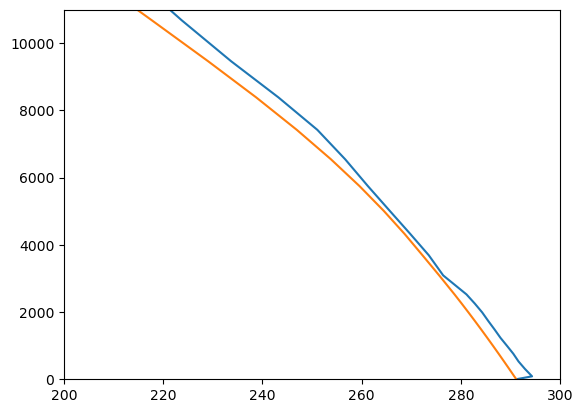

In [ ]:
#plt.plot(T_v_save_env[1],Z_height[1])
#plt.plot(T_v_save_parcel[1],Z_height[1])
#plt.plot(T_v_era_1,Z_era)
#plt.ylim(0,2000)
plt.plot(T_air[20],Z_height[20])
plt.plot(T_arr[20],Z_height[20])
plt.ylim(0,11000)
plt.xlim(200,300)

In [ ]:
Z_c

0.0